In [3]:
import os
import gc
import zarr
import yaml
import json
import numba
import numpy as np
import polars as pl
import pandas as pd
from tqdm import tqdm
import statsmodels.api as sm
from scipy import stats

from plotnine import *
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

In [ ]:
# Configuration and paths
mac = 20
pheno_list = None

# Load phenotype configuration
pheno_config_path = "/home/dnanexus/ukbgym/phenotype_config.yaml"
with open(pheno_config_path) as f:
    pheno_config = yaml.safe_load(f)

if pheno_list is None:
    pheno_list = pheno_config['biochemistry'] + pheno_config['overall_phenotype']
else:
    pheno_list = pheno_config[pheno_list]

eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'

# Load annotation configuration
config_path = "/home/dnanexus/ukbgym/config_wgs.yaml"
with open(config_path) as f:
    config = yaml.safe_load(f)

records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records).with_columns(
    pl.col("annotation_dir").cast(pl.Int8)
)

all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()

anno_config_df

category,annotation,color,label,annotation_dir
str,str,str,str,i8
"""plof_consequences""","""consequence_frameshift_variant""","""#E31A1C""","""VEP Frameshift""",1
"""plof_consequences""","""consequence_stop_gained""","""#FB9A99""","""VEP Stop Gained""",1
"""plof_consequences""","""consequence_splice_donor_varia…","""#6A1B9A""","""VEP Splice Donor""",1
"""plof_consequences""","""consequence_splice_acceptor_va…","""#AB47BC""","""VEP Splice Acceptor""",1
"""plof_consequences""","""consequence_start_lost""","""#E65100""","""VEP Start Lost""",1
…,…,…,…,…
"""vep_consequences""","""consequence_splice_acceptor_va…","""#AB47BC""","""VEP Splice Acceptor""",1
"""vep_consequences""","""consequence_start_lost""","""#E65100""","""VEP Start Lost""",1
"""vep_consequences""","""consequence_stop_lost""","""#FFB300""","""VEP Stop Lost""",1


In [5]:
anno = pl.scan_parquet("/home/dnanexus/data_dir/genebass352genes_olink371genes_annotated_251205_fillna.parquet")

existing_annos = [c for c in all_annotation_list if c in anno.collect_schema().names()]

# existing_annos = ['gpn_score', 'gpn_star_llr_calibrated_mean', 'cadd_raw']

# plof_cols = ['loftee_hc', 'loftee_lc']
# plof_cols = ['loftee_hc', 'loftee_lc', 'consequence_start_lost', 'consequence_stop_lost']

anno = (
    anno
    .filter(
        # Choose CDS
        (pl.col('vep_cds_relaxed')==True) &
        # ((pl.col('vep_cds') == True) | (pl.col('mane_cds') == True) | (pl.col('non_mane_cds') == True)) &

        # Only SNPs
        (pl.col('ref').str.len_chars()==1) & (pl.col('alt').str.len_chars()==1)
    )
    .select(
        set(['id', 'region', 'gene_name'])
        .union(set(existing_annos))
        # .union(set(plof_cols))
    )
    .with_columns(
        start_stop_lost = (pl.col('consequence_start_lost') == 1) | (pl.col('consequence_stop_lost') == 1)
    )
    .collect(engine='streaming')
)

anno

abexp_abs_max,ted_domain,mobi_curated_disorder_priority,five_prime_utr_variant_consequence_ustop_lost,gene_name,consequence_synonymous_variant,five_prime_utr_variant_consequence_ustop_gained,encode_pls,mobi_lip_full,delta_score,consequence_missense_variant,consequence_stop_gained,cadd_raw,promoterai_abs,encode_pels,score_pai3d,region,low_complexity_domain,absplice_dna_max,pangolin_score,five_prime_utr_variant_consequence_uaug_gained,absplice2_max,id,verphylop,loftee_lc,promoterai,loftee_hc,consequence_splice_acceptor_variant,gpn_star_llr_calibrated_mean,abexp_min,esmscoremissense,consequence_frameshift_variant,consequence_stop_lost,five_prime_utr_variant_consequence_uaug_lost,encode_tf,encode_dels,gpn_score,am_pathogenicity,consequence_splice_donor_variant,consequence_start_lost,encode_ca_tf,start_stop_lost
f32,bool,bool,u8,str,i32,u8,bool,bool,f32,i32,i32,f32,f32,bool,f32,str,bool,f32,f32,u8,f32,str,f32,i8,f32,i8,i32,f32,f32,f32,i32,i32,u8,bool,bool,f32,f32,i32,i32,bool,bool
1.997105,false,false,0,"""PLEKHO2""",0,0,false,true,0.87,1,0,6.585388,0.0,false,0.626882,"""ENSG00000241839""",false,0.29,0.82,0,0.531172,"""chr15:64859998:G:C""",9.133,0,0.0,0,0,-9.52998,-1.997105,-6.781,0,0,0,false,true,-12.04,0.6981,0,0,false,false
0.049098,false,true,0,"""KDM5B""",0,0,false,true,0.0,1,0,2.497457,0.0028,false,0.602516,"""ENSG00000117139""",true,0.001,0.0,0,0.000074,"""chr1:202729885:A:T""",4.968,0,-0.0028,0,0,-6.822783,-0.049098,-3.949,0,0,0,false,false,-8.92,0.0911,0,0,false,false
0.078567,true,false,0,"""ACRV1""",0,0,false,false,0.0,1,0,4.886163,0.0,false,0.758137,"""ENSG00000134940""",false,0.003,0.0,0,0.000395,"""chr11:125672628:A:G""",3.389,0,0.0,0,0,-7.618337,-0.078567,-12.142,0,0,0,false,false,-6.64,0.9957,0,0,false,false
0.026393,false,false,0,"""KDM5B""",0,0,false,false,0.0,1,0,1.024761,0.0,false,0.254022,"""ENSG00000117139""",false,0.003,0.0,0,0.000341,"""chr1:202742800:C:T""",-0.317,0,0.0,0,0,-1.582607,-0.026393,-3.762,0,0,0,false,true,-2.59,0.0651,0,0,false,false
0.07843,false,true,0,"""KDM5B""",0,0,false,false,0.0,1,0,2.466337,0.0,false,0.412907,"""ENSG00000117139""",false,0.003,0.0,0,0.000369,"""chr1:202735550:A:G""",2.362,0,0.0,0,0,-3.622938,-0.07843,-3.944,0,0,0,false,false,-5.7,0.0902,0,0,false,false
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
0.03127,true,false,0,"""ABCG5""",1,0,false,false,0.01,0,0,0.59692,0.0,false,0.0,"""ENSG00000138075""",false,0.005817,0.01,0,0.000663,"""chr2:43825007:T:C""",1.203,0,0.0,0,0,0.031151,-0.03127,0.0,0,0,0,false,false,-2.25,0.0,0,0,false,false
0.089759,true,false,0,"""ABCC2""",0,0,false,false,0.0,1,0,4.454148,0.0,false,0.741718,"""ENSG00000023839""",false,0.00291,0.0,0,0.000348,"""chr10:99819216:C:A""",7.101,0,0.0,0,0,-7.166539,-0.089759,-6.958,0,0,0,false,false,-8.51,0.4961,0,0,false,false
0.1407,false,false,0,"""ABCC2""",0,0,false,false,0.08,1,0,4.481823,0.0,false,0.77205,"""ENSG00000023839""",false,0.009023,0.02,0,0.002292,"""chr10:99800490:A:T""",8.683,0,0.0,0,0,-6.454949,-0.1407,-4.605,0,0,0,false,false,-7.68,0.4567,0,0,false,false


## Other pLoF

In [ ]:
selected_annos = anno_config_df.filter(
    pl.col('category').is_in(['plof_consequences']) # plof consequences
)['annotation'].to_list()
selected_annos = ['gpn_star_llr_calibrated_mean', 'cadd_raw']

plof_annos = set(['start_stop_lost', 'loftee_lc', 'loftee_hc'])

plof_df = (
    anno
    .unpivot(
        index=set(['id', 'region', 'gene_name']).union(plof_annos),
        on=selected_annos,
        variable_name='annotation',
        value_name='annotation_score',
    )
    .unpivot(
        index = ['id', 'region', 'gene_name', 'annotation', 'annotation_score'],
        variable_name='plof_type',
        value_name='plof_score',
    )
    .filter(
        pl.col('plof_score') == 1
    )
    .join(
        anno_config_df.drop('category').unique(), 
        on='annotation'
    )
    .join(
        anno_config_df.rename({
            'annotation':'plof_type', 
            'annotation_dir':'plof_dir',
            'label':'label_plof'
        }).select(['plof_type', 'plof_dir', 'label_plof']).unique(),
        on='plof_type'
    )
    .with_columns(
        annotation_score_dircorr = (pl.col("annotation_score")*pl.col("annotation_dir")).cast(pl.Float32),
    )
)

plof_df

id,region,gene_name,annotation,annotation_score,plof_type,plof_score,color,label,annotation_dir,plof_dir,label_plof,annotation_score_dircorr
str,str,str,str,f32,str,i8,str,str,i8,i8,str,f32
"""chr10:96156324:T:C""","""ENSG00000177853""","""ZNF518A""","""gpn_star_llr_calibrated_mean""",-5.747846,"""start_stop_lost""",1,"""#942c80""","""GPN-Star""",-1,1,"""Start/Stop Lost""",5.747846
"""chr20:50691126:C:G""","""ENSG00000042062""","""RIPOR3""","""gpn_star_llr_calibrated_mean""",-6.664073,"""start_stop_lost""",1,"""#942c80""","""GPN-Star""",-1,1,"""Start/Stop Lost""",6.664073
"""chr1:212414757:T:C""","""ENSG00000065600""","""PACC1""","""gpn_star_llr_calibrated_mean""",-8.417483,"""start_stop_lost""",1,"""#942c80""","""GPN-Star""",-1,1,"""Start/Stop Lost""",8.417483
"""chr11:11842188:G:C""","""ENSG00000170242""","""USP47""","""gpn_star_llr_calibrated_mean""",-10.357368,"""start_stop_lost""",1,"""#942c80""","""GPN-Star""",-1,1,"""Start/Stop Lost""",10.357368
"""chr20:3804961:A:G""","""ENSG00000101224""","""CDC25B""","""gpn_star_llr_calibrated_mean""",-8.790766,"""start_stop_lost""",1,"""#942c80""","""GPN-Star""",-1,1,"""Start/Stop Lost""",8.790766
…,…,…,…,…,…,…,…,…,…,…,…,…
"""chr17:39712049:T:C""","""ENSG00000141736""","""ERBB2""","""cadd_raw""",4.97525,"""loftee_hc""",1,"""#1f77b4""","""CADD Raw""",1,1,"""LOFTEE HC""",4.97525
"""chr10:96223918:C:A""","""ENSG00000095585""","""BLNK""","""cadd_raw""",6.613621,"""loftee_hc""",1,"""#1f77b4""","""CADD Raw""",1,1,"""LOFTEE HC""",6.613621
"""chr2:227144525:A:C""","""ENSG00000081052""","""COL4A4""","""cadd_raw""",6.032987,"""loftee_hc""",1,"""#1f77b4""","""CADD Raw""",1,1,"""LOFTEE HC""",6.032987


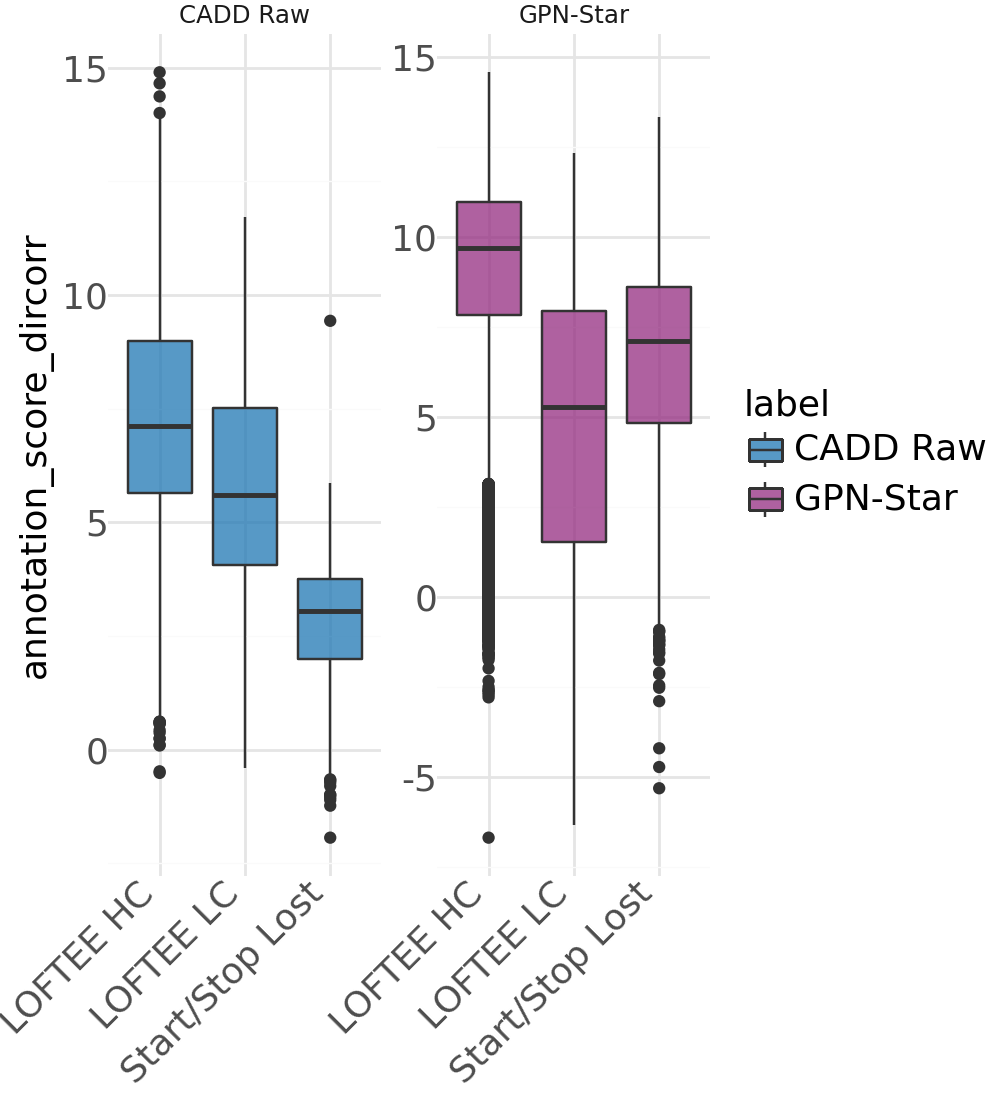

In [7]:
color_dict = dict(zip(anno_config_df['label'], anno_config_df['color']))

(
    ggplot(
        plof_df,
        aes(y='annotation_score_dircorr', x='label_plof', fill='label')
    )
    + geom_boxplot(width=0.75, alpha=0.75)
    + facet_wrap('~label', scales='free_y', ncol=3)
    + scale_fill_manual(values=color_dict)
    + labs(x='')
    + theme_minimal()
    + theme(
        figure_size=(5, 5.5),
        axis_text_x=element_text(rotation=45, hjust=1),
        axis_text=element_text(size=13),
        axis_title=element_text(size=13),
        legend_text=element_text(size=13),
        legend_title=element_text(size=13),
        plot_background=element_rect(fill="white", color="white"),
    )
)

## Look at Phenotypes

In [10]:
plof_stats_df = (
    plof_df
    .group_by(['label', 'label_plof'])
    .agg(
        n_variants = pl.len(),
        mean_annotation_score = pl.col('annotation_score_dircorr').mean(),
        std_annotation_score = pl.col('annotation_score_dircorr').std(),
        qtl25_annotation_score = pl.col('annotation_score_dircorr').quantile(0.25),
        qtl75_annotation_score = pl.col('annotation_score_dircorr').quantile(0.75),
    )
    .sort(['label', 'label_plof'])
)

plof_stats_df

label,label_plof,n_variants,mean_annotation_score,std_annotation_score,qtl25_annotation_score,qtl75_annotation_score
str,str,u64,f32,f32,f32,f32
"""CADD Raw""","""LOFTEE HC""",21607,7.296255,1.977515,5.650827,8.986744
"""CADD Raw""","""LOFTEE LC""",1191,5.608735,2.488167,4.064864,7.52164
"""CADD Raw""","""Start/Stop Lost""",1241,2.820768,1.254906,1.998258,3.751317
"""GPN-Star""","""LOFTEE HC""",21607,8.990886,2.845909,7.833182,10.957524
"""GPN-Star""","""LOFTEE LC""",1191,4.888408,3.612128,1.547046,7.95476
"""GPN-Star""","""Start/Stop Lost""",1241,6.500586,2.974396,4.837677,8.599945


In [7]:
anno = "GPN-Star"

dbs_plof_df = (
    plof_df
    .filter(
        (pl.col('label') == anno) &
        (pl.col('plof_type') == 'dubious_plof') &
        (pl.col('annotation_score_dircorr') > plof_stats_df.filter(
                (pl.col('label') == anno) &
                (pl.col('plof_type') == 'loftee_hc')
            )
            .select('qtl75_annotation_score')
            .item()
        )
    )
)

dbs_plof_df

id,region,gene_name,annotation,annotation_score,plof_type,plof_score,category,color,label,annotation_dir,annotation_score_dircorr
str,str,str,str,f64,str,i8,str,str,str,i8,f32
"""chr11:11956173:T:C""","""ENSG00000170242""","""USP47""","""gpn_star_llr_calibrated_mean""",-10.967503,"""dubious_plof""",1,"""conservation""","""#942c80""","""GPN-Star""",-1,10.967503
"""chr2:209730396:G:T""","""ENSG00000078018""","""MAP2""","""gpn_star_llr_calibrated_mean""",-12.674371,"""dubious_plof""",1,"""conservation""","""#942c80""","""GPN-Star""",-1,12.674371
"""chr20:38488434:T:G""","""ENSG00000170471""","""RALGAPB""","""gpn_star_llr_calibrated_mean""",-12.223708,"""dubious_plof""",1,"""conservation""","""#942c80""","""GPN-Star""",-1,12.223708
"""chr6:16238695:T:A""","""ENSG00000137198""","""GMPR""","""gpn_star_llr_calibrated_mean""",-11.219679,"""dubious_plof""",1,"""conservation""","""#942c80""","""GPN-Star""",-1,11.219679
"""chr6:16238696:G:T""","""ENSG00000137198""","""GMPR""","""gpn_star_llr_calibrated_mean""",-11.345552,"""dubious_plof""",1,"""conservation""","""#942c80""","""GPN-Star""",-1,11.345552
…,…,…,…,…,…,…,…,…,…,…,…
"""chr1:166876232:A:T""","""ENSG00000152382""","""TADA1""","""gpn_star_llr_calibrated_mean""",-11.005068,"""dubious_plof""",1,"""conservation""","""#942c80""","""GPN-Star""",-1,11.005068
"""chr22:40323239:T:C""","""ENSG00000100354""","""TNRC6B""","""gpn_star_llr_calibrated_mean""",-11.473181,"""dubious_plof""",1,"""conservation""","""#942c80""","""GPN-Star""",-1,11.473181
"""chr22:40323241:A:T""","""ENSG00000100354""","""TNRC6B""","""gpn_star_llr_calibrated_mean""",-13.33519,"""dubious_plof""",1,"""conservation""","""#942c80""","""GPN-Star""",-1,13.33519


In [8]:
dbs_plof_df['gene_name'].value_counts(sort=True)

gene_name,count
str,u64
"""GMPR""",2
"""PAX2""",2
"""TADA1""",2
"""TNRC6B""",2
"""USP47""",1
…,…
"""EPC2""",1
"""HNF1A""",1
"""SOX2""",1


In [9]:
# Get gene trait associations

plof = pl.read_parquet('/home/dnanexus/data_dir/association_files/rvat_EUR_500k_regenie.parquet').with_columns(
    phenotype = (pl.col('trait') + '_int'),
    region = pl.col('gene_id'),
    rvat_pval = (10** -pl.col("neg_log10p")),
).filter(
    (pl.col('trait_type') == 'quantitative')
)

loftee_corr = pl.read_parquet("/home/dnanexus/data_dir/association_files/loftee_correlation_quantitative_wgs_EUR_genebass1e6_maf1e3_snp_consistent.parquet")

gene_trait_df = loftee_corr.join(plof[['region', 'phenotype', 'beta', 'rvat_pval']], on=['region', 'phenotype'], how='inner').filter(
    pl.col('loftee_corr')*pl.col('beta') > 0
).with_columns(
    corr_dir = pl.col('loftee_corr')/pl.col('loftee_corr').abs()
)
gene_trait_df

region,gene_name,phenotype,loftee_corr,n_variants,beta,rvat_pval,corr_dir
str,str,str,f64,u64,f64,f64,f64
"""ENSG00000116183""","""PAPPA2""","""arm_fatfree_mass_right_int""",-0.014747,82603,-0.195409,9.1637e-8,-1.0
"""ENSG00000129083""","""COPB1""","""arm_fatfree_mass_right_int""",-0.014338,13594,-0.397279,0.006626,-1.0
"""ENSG00000100578""","""KIAA0586""","""arm_fatfree_mass_right_int""",-0.010787,28541,-0.058463,0.000305,-1.0
"""ENSG00000157766""","""ACAN""","""arm_fatfree_mass_right_int""",-0.036259,20244,-0.436618,6.0395e-11,-1.0
"""ENSG00000140443""","""IGF1R""","""arm_fatfree_mass_right_int""",-0.013644,82469,-0.412619,2.8609e-8,-1.0
…,…,…,…,…,…,…,…
"""ENSG00000112077""","""RHAG""","""reticulocyte_count_int""",0.033239,9849,0.952411,1.8038e-41,1.0
"""ENSG00000029534""","""ANK1""","""reticulocyte_count_int""",0.02685,54620,0.656849,2.1682e-10,1.0
"""ENSG00000197969""","""VPS13A""","""reticulocyte_count_int""",0.003971,55477,0.176348,2.1188e-7,1.0


In [12]:
appv = pl.scan_parquet("/home/dnanexus/data_dir/appv_files/avg_pheno_per_var_quantitative_EUR_genebass1e6_PRScorr_with_percentiles.parquet")

# Create a lazy frame with the unique keys
anno_keys = plof_df.select(pl.col('id').unique()).lazy()

# Chain the filter and the much faster semi join
appv = (
    appv
    .join(
        anno_keys, on='id', how='semi'
    )
    .filter(
        pl.col('n_individuals') <= mac
    )
    .select(
        ['id', 'phenotype', 'mean_pheno_value', 'n_individuals']
    )
)

In [55]:
anno_pheno_df = (
    # A. Use a semi join for efficient filtering (more memory-safe than 'is_in')
    appv
    # B. Join the other two dataframes
    .join(
        plof_df.lazy().drop([c for c in plof_df.columns if 'is_nan' in c]), 
        on="id", 
        how="inner"
    )
    .join(
        gene_trait_df.lazy(), 
        on=["region", "phenotype"], 
        how="inner"
    )
    .with_columns(
        mean_pheno_value_dircor = pl.col('mean_pheno_value')*pl.col('corr_dir')
    )
    .collect(engine='streaming')
)

anno_pheno_df

id,phenotype,mean_pheno_value,n_individuals,region,gene_name,annotation,annotation_score,plof_type,plof_score,category,color,label,annotation_dir,annotation_score_dircorr,gene_name_right,loftee_corr,n_variants,beta,rvat_pval,corr_dir,mean_pheno_value_dircor
str,str,f32,u32,str,str,str,f64,str,i8,str,str,str,i8,f32,str,f64,u64,f64,f64,f64,f64
"""chr2:21006087:C:T""","""alanine_aminotransferase_int""",-0.011021,19,"""ENSG00000084674""","""APOB""","""gpn_score""",-5.26,"""loftee_hc""",1,"""conservation""","""pink""","""GPN-MSA""",-1,5.26,"""APOB""",0.028104,11795,0.190438,9.6228e-11,1.0,-0.011021
"""chr2:21006087:C:T""","""alanine_aminotransferase_int""",-0.011021,19,"""ENSG00000084674""","""APOB""","""gpn_star_llr_calibrated_mean""",-5.957812,"""loftee_hc""",1,"""conservation""","""#942c80""","""GPN-Star""",-1,5.957812,"""APOB""",0.028104,11795,0.190438,9.6228e-11,1.0,-0.011021
"""chr2:21006087:C:T""","""alanine_aminotransferase_int""",-0.011021,19,"""ENSG00000084674""","""APOB""","""cadd_raw""",9.299354,"""loftee_hc""",1,"""genetic_diversity""","""#1f77b4""","""CADD Raw""",1,9.299354,"""APOB""",0.028104,11795,0.190438,9.6228e-11,1.0,-0.011021
"""chr2:21007580:A:C""","""alanine_aminotransferase_int""",0.270138,1,"""ENSG00000084674""","""APOB""","""gpn_score""",-9.32,"""loftee_hc""",1,"""conservation""","""pink""","""GPN-MSA""",-1,9.32,"""APOB""",0.028104,11795,0.190438,9.6228e-11,1.0,0.270138
"""chr2:21007580:A:C""","""alanine_aminotransferase_int""",0.270138,1,"""ENSG00000084674""","""APOB""","""gpn_star_llr_calibrated_mean""",-9.19716,"""loftee_hc""",1,"""conservation""","""#942c80""","""GPN-Star""",-1,9.19716,"""APOB""",0.028104,11795,0.190438,9.6228e-11,1.0,0.270138
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""chr20:37256888:A:T""","""whole_body_water_mass_int""",0.655092,1,"""ENSG00000118702""","""GHRH""","""gpn_star_llr_calibrated_mean""",-8.766029,"""dubious_plof""",1,"""conservation""","""#942c80""","""GPN-Star""",-1,8.766029,"""GHRH""",-0.023754,4585,-0.322347,2.8641e-8,-1.0,-0.655092
"""chr20:37256888:A:T""","""whole_body_water_mass_int""",0.655092,1,"""ENSG00000118702""","""GHRH""","""cadd_raw""",4.157141,"""dubious_plof""",1,"""genetic_diversity""","""#1f77b4""","""CADD Raw""",1,4.157141,"""GHRH""",-0.023754,4585,-0.322347,2.8641e-8,-1.0,-0.655092
"""chr20:37254313:G:A""","""whole_body_water_mass_int""",-0.230922,8,"""ENSG00000118702""","""GHRH""","""gpn_score""",-2.38,"""loftee_hc""",1,"""conservation""","""pink""","""GPN-MSA""",-1,2.38,"""GHRH""",-0.023754,4585,-0.322347,2.8641e-8,-1.0,0.230922


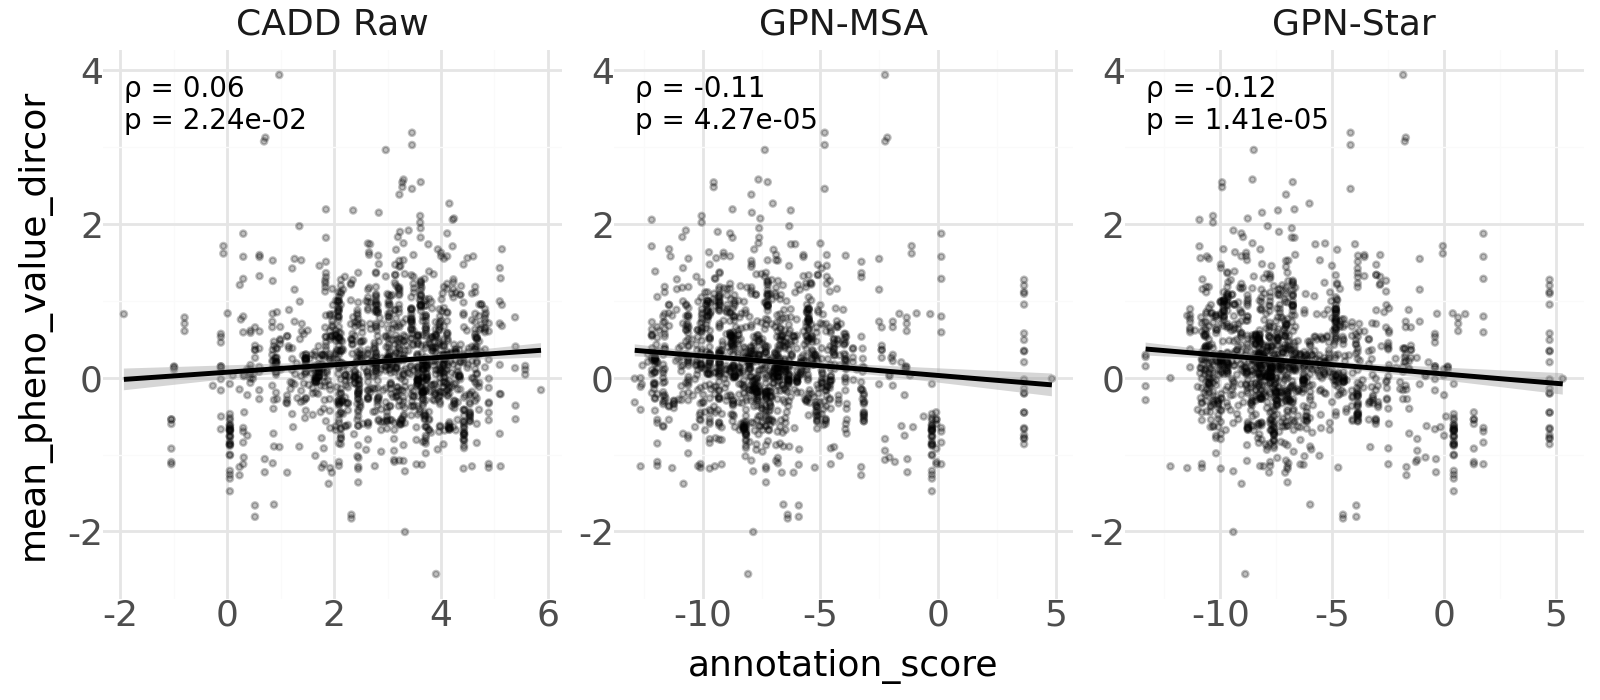

In [82]:
from scipy.stats import spearmanr

# 1. PREPARE DATA
plot_data = anno_pheno_df.filter(
    pl.col('plof_type') == 'dubious_plof'
    # pl.col('plof_type') == 'loftee_lc'
)

# 2. DEFINE CUSTOM FUNCTION
def get_spearman_stats(df):
    res = spearmanr(df['annotation_score'], df['mean_pheno_value_dircor'])
    
    # Use Python's f-string here (it supports .2e, .2f, etc.)
    txt = f"ρ = {res.statistic:.2f}\np = {res.pvalue:.2e}"
    
    return pl.DataFrame({
        "label": df['label'][0],
        "label_text": [txt],  # <--- Return the pre-formatted string
        "x_pos": [df['annotation_score'].min()],
        "y_pos": [df['mean_pheno_value_dircor'].max()]
    })

# 3. APPLY TO GROUPS
cor_df = (
    plot_data
    .group_by("label", maintain_order=True)
    .map_groups(get_spearman_stats)
)

# 4. PLOT
(
    ggplot(plot_data, aes(x='annotation_score', y='mean_pheno_value_dircor'))
    + geom_point(color='black', alpha=0.25, size=0.75)
    + geom_smooth(method='lm', se=True)
    
    # Add the text with the p-value
    + geom_text(
        data=cor_df,
        mapping=aes(x='x_pos', y='y_pos', label='label_text'),
        ha='left',
        va='top',
        size=10,
        inherit_aes=False
    )
    
    + facet_wrap('~label', scales='free', ncol=3)
    + theme_minimal()
    + theme(
        figure_size=(8, 3.5),
        axis_text=element_text(size=13),
        axis_title=element_text(size=13),
        strip_text=element_text(size=13)
    )
)

In [56]:
plof_stats_df = (
    anno_pheno_df
    .select(['id', 'gene_name', 'label', 'plof_type', 'n_individuals']).unique()
    .group_by(['label', 'plof_type'])
    .agg(
        n_variants = pl.len(),
        sum_ac = pl.sum('n_individuals')
        # mean_annotation_score = pl.col('annotation_score_dircorr').mean(),
        # std_annotation_score = pl.col('annotation_score_dircorr').std(),
        # qtl25_annotation_score = pl.col('annotation_score_dircorr').quantile(0.25),
        # qtl75_annotation_score = pl.col('annotation_score_dircorr').quantile(0.75),
    )
    .sort(['label', 'plof_type'])
)

plof_stats_df

label,plof_type,n_variants,sum_ac
str,str,u64,u32
"""CADD Raw""","""dubious_plof""",455,2761
"""CADD Raw""","""loftee_hc""",10304,80155
"""CADD Raw""","""loftee_lc""",460,2973
"""GPN-MSA""","""dubious_plof""",455,2761
"""GPN-MSA""","""loftee_hc""",10304,80155
"""GPN-MSA""","""loftee_lc""",460,2973
"""GPN-Star""","""dubious_plof""",455,2761
"""GPN-Star""","""loftee_hc""",10304,80155
"""GPN-Star""","""loftee_lc""",460,2973


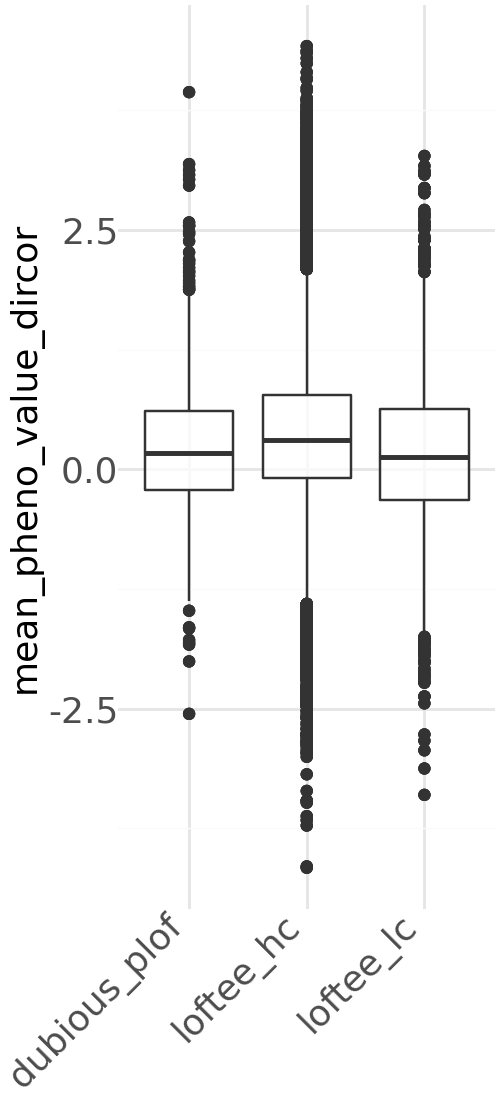

In [69]:
pheno_plof = anno_pheno_df[['id', 'gene_name', 'phenotype', 'plof_type', 'mean_pheno_value_dircor', 'label']].unique()

(
    ggplot(
        pheno_plof,
        aes(x='plof_type', y='mean_pheno_value_dircor')
    )
    + geom_boxplot(width=0.75, alpha=0.75)
    + labs(x='')
    + theme_minimal()
    + theme(
        figure_size=(2.5, 5.5),
        axis_text_x=element_text(rotation=45, hjust=1),
        axis_text=element_text(size=13),
        axis_title=element_text(size=13),
        legend_text=element_text(size=13),
        legend_title=element_text(size=13),
    )
)

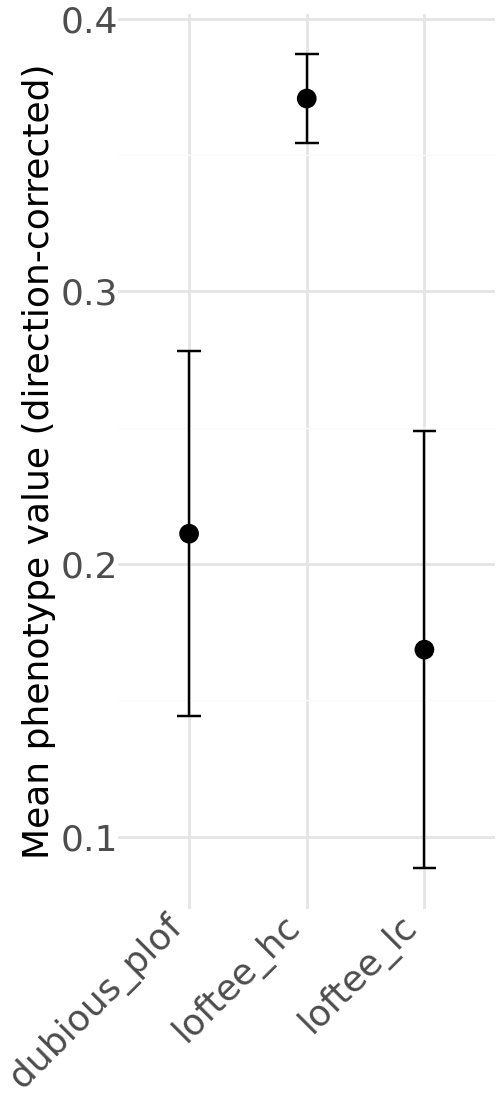

In [73]:
avg_plof_plot = (
    pheno_plof
    .group_by(['plof_type'])
    .agg(
        n_vars = pl.col('id').n_unique(),
        median_pheno = pl.col('mean_pheno_value_dircor').median(),
        mean_pheno = pl.col('mean_pheno_value_dircor').mean(),
        std_pheno = pl.col('mean_pheno_value_dircor').std(),
    )
    .with_columns(
        se_pheno = pl.col('std_pheno') / pl.col('n_vars').sqrt()
    )
    .with_columns(
        ci_low_pheno = pl.col('mean_pheno') - 1.96*pl.col('se_pheno'),
        ci_high_pheno = pl.col('mean_pheno') + 1.96*pl.col('se_pheno'),
    )
)

(
    ggplot(
        avg_plof_plot,
        aes(x='plof_type', y='mean_pheno')
    )
    + geom_point(size=3)
    + geom_errorbar(
        aes(ymin='ci_low_pheno', ymax='ci_high_pheno'),
        width=0.2,
    )
    + labs(x='', y='Mean phenotype value (direction-corrected)')
    + theme_minimal()
    + theme(
        figure_size=(2.5, 5.5),
        axis_text_x=element_text(rotation=45, hjust=1),
        axis_text=element_text(size=13),
        axis_title=element_text(size=13),
        legend_text=element_text(size=13),
        legend_title=element_text(size=13),
    )
)

In [84]:
median_dbs_plof_pheno = avg_plof_plot.filter(pl.col('plof_type') == 'dubious_plof')['median_pheno'].item()

pheno_plof_strat = (
    anno_pheno_df
    .with_columns(
        plof_pheno_type = (
            pl.when(pl.col('plof_type') == 'loftee_hc')
            .then(
                # pl.when(pl.col('mean_pheno_value_dircor') > median_dbs_plof_pheno)
                pl.when(pl.col('mean_pheno_value_dircor') > 0)
                .then(pl.lit('high_pheno_loftee_hc'))
                .otherwise(pl.lit('low_pheno_loftee_hc'))
            )
            .otherwise(pl.col('plof_type'))
        ) 
    )
)

pheno_plof_strat

id,phenotype,mean_pheno_value,n_individuals,region,gene_name,annotation,annotation_score,plof_type,plof_score,category,color,label,annotation_dir,annotation_score_dircorr,gene_name_right,loftee_corr,n_variants,beta,rvat_pval,corr_dir,mean_pheno_value_dircor,plof_pheno_type
str,str,f32,u32,str,str,str,f64,str,i8,str,str,str,i8,f32,str,f64,u64,f64,f64,f64,f64,str
"""chr2:21006087:C:T""","""alanine_aminotransferase_int""",-0.011021,19,"""ENSG00000084674""","""APOB""","""gpn_score""",-5.26,"""loftee_hc""",1,"""conservation""","""pink""","""GPN-MSA""",-1,5.26,"""APOB""",0.028104,11795,0.190438,9.6228e-11,1.0,-0.011021,"""low_pheno_loftee_hc"""
"""chr2:21006087:C:T""","""alanine_aminotransferase_int""",-0.011021,19,"""ENSG00000084674""","""APOB""","""gpn_star_llr_calibrated_mean""",-5.957812,"""loftee_hc""",1,"""conservation""","""#942c80""","""GPN-Star""",-1,5.957812,"""APOB""",0.028104,11795,0.190438,9.6228e-11,1.0,-0.011021,"""low_pheno_loftee_hc"""
"""chr2:21006087:C:T""","""alanine_aminotransferase_int""",-0.011021,19,"""ENSG00000084674""","""APOB""","""cadd_raw""",9.299354,"""loftee_hc""",1,"""genetic_diversity""","""#1f77b4""","""CADD Raw""",1,9.299354,"""APOB""",0.028104,11795,0.190438,9.6228e-11,1.0,-0.011021,"""low_pheno_loftee_hc"""
"""chr2:21007580:A:C""","""alanine_aminotransferase_int""",0.270138,1,"""ENSG00000084674""","""APOB""","""gpn_score""",-9.32,"""loftee_hc""",1,"""conservation""","""pink""","""GPN-MSA""",-1,9.32,"""APOB""",0.028104,11795,0.190438,9.6228e-11,1.0,0.270138,"""high_pheno_loftee_hc"""
"""chr2:21007580:A:C""","""alanine_aminotransferase_int""",0.270138,1,"""ENSG00000084674""","""APOB""","""gpn_star_llr_calibrated_mean""",-9.19716,"""loftee_hc""",1,"""conservation""","""#942c80""","""GPN-Star""",-1,9.19716,"""APOB""",0.028104,11795,0.190438,9.6228e-11,1.0,0.270138,"""high_pheno_loftee_hc"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""chr20:37256888:A:T""","""whole_body_water_mass_int""",0.655092,1,"""ENSG00000118702""","""GHRH""","""gpn_star_llr_calibrated_mean""",-8.766029,"""dubious_plof""",1,"""conservation""","""#942c80""","""GPN-Star""",-1,8.766029,"""GHRH""",-0.023754,4585,-0.322347,2.8641e-8,-1.0,-0.655092,"""dubious_plof"""
"""chr20:37256888:A:T""","""whole_body_water_mass_int""",0.655092,1,"""ENSG00000118702""","""GHRH""","""cadd_raw""",4.157141,"""dubious_plof""",1,"""genetic_diversity""","""#1f77b4""","""CADD Raw""",1,4.157141,"""GHRH""",-0.023754,4585,-0.322347,2.8641e-8,-1.0,-0.655092,"""dubious_plof"""
"""chr20:37254313:G:A""","""whole_body_water_mass_int""",-0.230922,8,"""ENSG00000118702""","""GHRH""","""gpn_score""",-2.38,"""loftee_hc""",1,"""conservation""","""pink""","""GPN-MSA""",-1,2.38,"""GHRH""",-0.023754,4585,-0.322347,2.8641e-8,-1.0,0.230922,"""high_pheno_loftee_hc"""


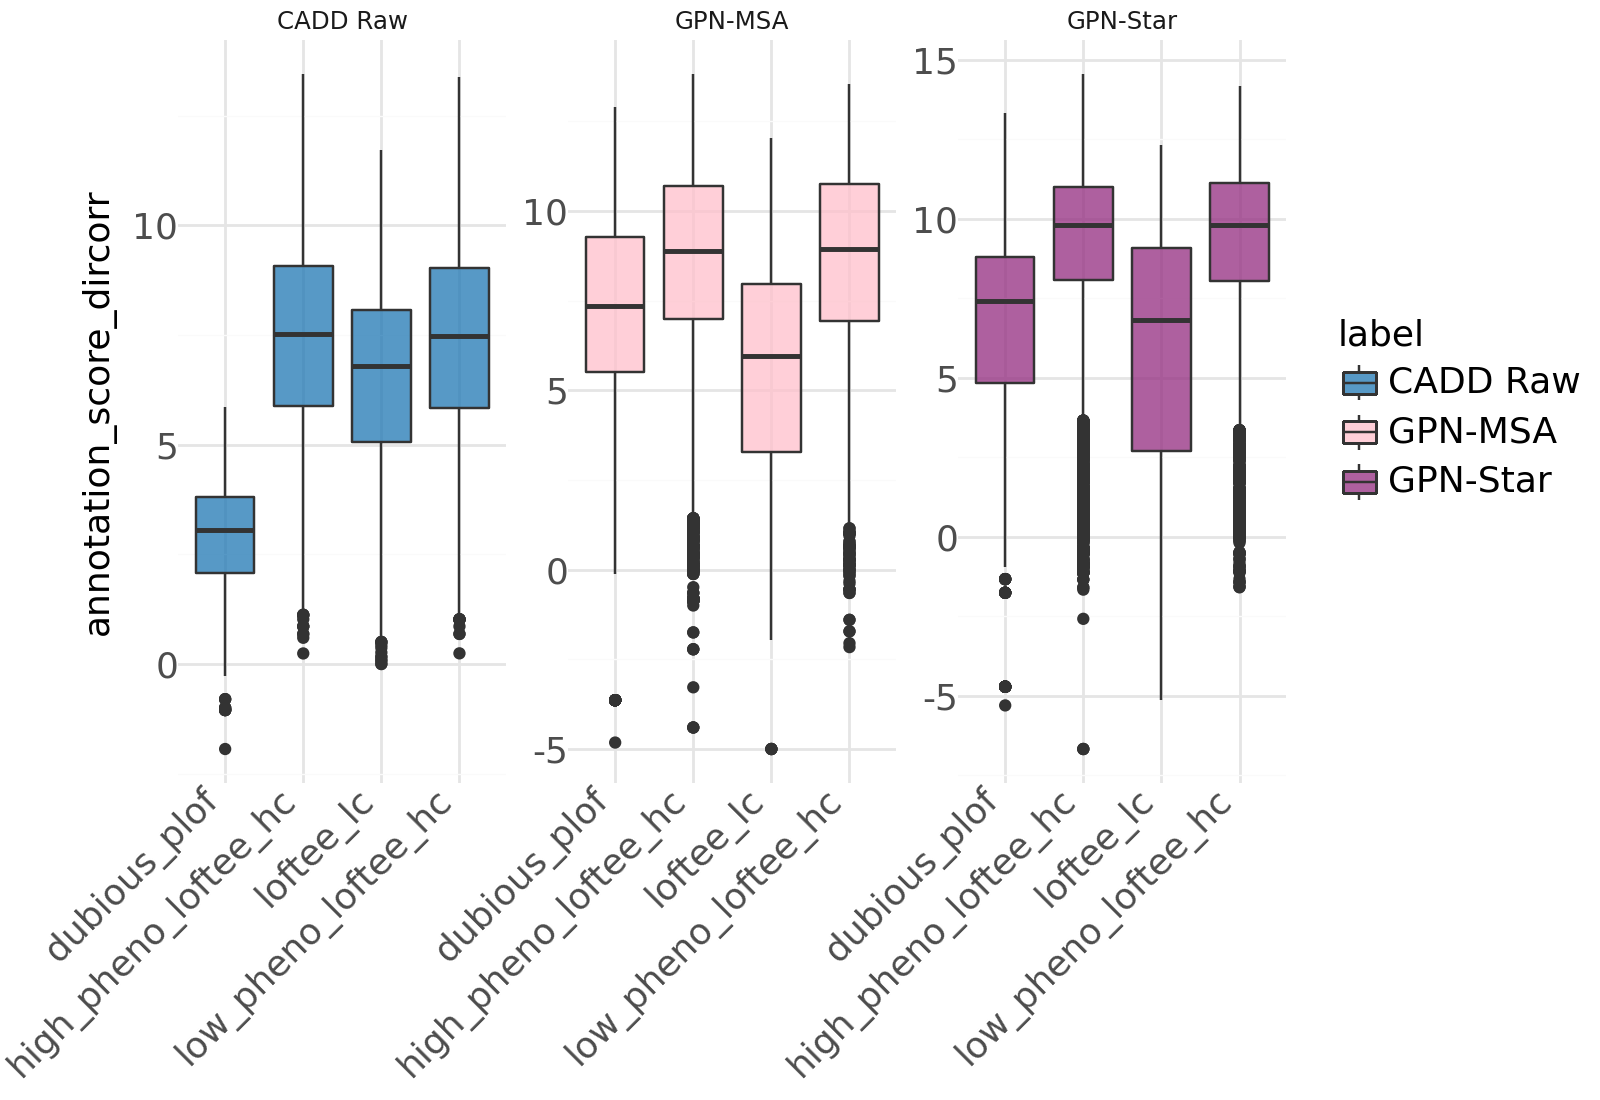

In [85]:
color_dict = dict(zip(anno_config_df['label'], anno_config_df['color']))

(
    ggplot(
        pheno_plof_strat,
        aes(y='annotation_score_dircorr', x='plof_pheno_type', fill='label')
    )
    + geom_boxplot(width=0.75, alpha=0.75)
    + facet_wrap('~label', scales='free_y', ncol=3)
    + scale_fill_manual(values=color_dict)
    + labs(x='')
    + theme_minimal()
    + theme(
        figure_size=(8, 5.5),
        axis_text_x=element_text(rotation=45, hjust=1),
        axis_text=element_text(size=13),
        axis_title=element_text(size=13),
        legend_text=element_text(size=13),
        legend_title=element_text(size=13),
    )
)